# Ghana PM2.5 Air Quality Prediction — Multivariate Regression

**Mission / Problem.** Fine particulate matter (PM2.5) is a leading environmental health
risk in Ghanaian cities, driving respiratory and cardiovascular illness. Levels spike
dramatically during the dry **Harmattan** season (Nov–Mar) yet many areas lack real-time
monitoring.

**Solution.** A regression model that predicts daily PM2.5 for a given Ghanaian city and
date, learned from 20 years of data (2005–2025), so air quality can be estimated where
physical sensors are absent.

**Dataset.** *Gridded Daily PM2.5 at 1 km resolution — Ghana (2005–2024/25)*, city-level
daily aggregation. Source: Lamont-Doherty Earth Observatory, Columbia University
(Zenodo record 17920004). 153,400 daily records across 20 cities.
Target = `PM25` (µg/m³, continuous).


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load the data

In [2]:
df = pd.read_csv('ghana_pm25_combined.csv')
print('Shape:', df.shape)
df.head()

Shape: (153400, 3)


,Date,City,PM25
0,2005-01-01,Accra,38.3
1,2005-01-01,Bolgatanga,70.9
2,2005-01-01,Cape Coast,39.5
3,2005-01-01,Dambai,50.6
4,2005-01-01,Damongo,111.5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153400 entries, 0 to 153399
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    153400 non-null  str    
 1   City    153400 non-null  str    
 2   PM25    153400 non-null  float64
dtypes: float64(1), str(2)
memory usage: 3.5 MB


In [4]:
df.describe()

,PM25
count,153400.000000
mean,34.434272
std,22.939740
min,6.600000
25%,21.500000
50%,24.600000
75%,35.500000
max,152.200000


## 3. Cleaning

We check for the three things that would break a regression: missing values, duplicate
rows, and impossible (negative) PM2.5 readings.

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('Negative PM2.5 values:', (df['PM25'] < 0).sum())

Missing values per column:
Date    0
City    0
PM25    0
dtype: int64

Duplicate rows: 0
Negative PM2.5 values: 0


**Interpretation.** The dataset is already clean — no missing values, no duplicate
rows, and no physically impossible negative readings. The only cleaning step is parsing
`Date` into a proper datetime so we can engineer time features from it.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Cities:', df['City'].nunique())

Date range: 2005-01-01 to 2025-12-31
Cities: 20


## 4. Feature Engineering — turning non-numeric columns into numeric

The raw data has only `Date` (a string) and `City` (a category). A model cannot learn
from these directly, so we convert both into numeric features.

**From `Date` we extract:**
- `Year` — captures any long-term trend across 2005–2025
- `Month` — 1–12
- `DayOfYear` — 1–366, captures the annual seasonal cycle
- `Harmattan` — a 0/1 flag: 1 during the dusty dry season (Nov, Dec, Jan, Feb, Mar)

The Harmattan flag encodes Ghana's dry-season dust, which is the strongest physical
driver of PM2.5.

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Harmattan'] = df['Month'].isin([11, 12, 1, 2, 3]).astype(int)

# Quick evidence that the Harmattan flag is meaningful
print(df.groupby('Harmattan')['PM25'].mean())

Harmattan
0    22.681200
1    51.064721
Name: PM25, dtype: float64


**Interpretation.** Average PM2.5 is more than **double** during Harmattan months
(~51 µg/m³) versus the rest of the year (~23 µg/m³). This single engineered feature
carries a large share of the predictive signal.

### One-hot encoding the `City` column

`City` is a text category with 20 values. We convert it to numeric using one-hot
encoding. `drop_first=True` drops one city column to avoid the **dummy-variable trap**
(perfect multicollinearity, where the dropped category is implied by all others being 0).

In [8]:
df_model = df.drop(columns=['Date'])  # Date fully replaced by engineered features
df_encoded = pd.get_dummies(df_model, columns=['City'], drop_first=True)

# Convert any boolean dummy columns to int (0/1) for clean scaling
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print('Shape after encoding:', df_encoded.shape)
df_encoded.head()

Shape after encoding: (153400, 24)


,PM25,Year,Month,DayOfYear,Harmattan,City_Bolgatanga,City_Cape Coast,City_Dambai,City_Damongo,City_Goaso,City_Ho,City_Kintampo,City_Koforidua,City_Kumasi,City_Nalerigu,City_Navrongo,City_Sefwi Wiawso,City_Sekondi-Takoradi,City_Somanya,City_Sunyani,City_Tamale,City_Techiman,City_Tema,City_Wa
0,38.3,2005,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,70.9,2005,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,39.5,2005,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,50.6,2005,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,111.5,2005,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 5. Visualizations & Interpretation

### 5.1 Correlation heatmap

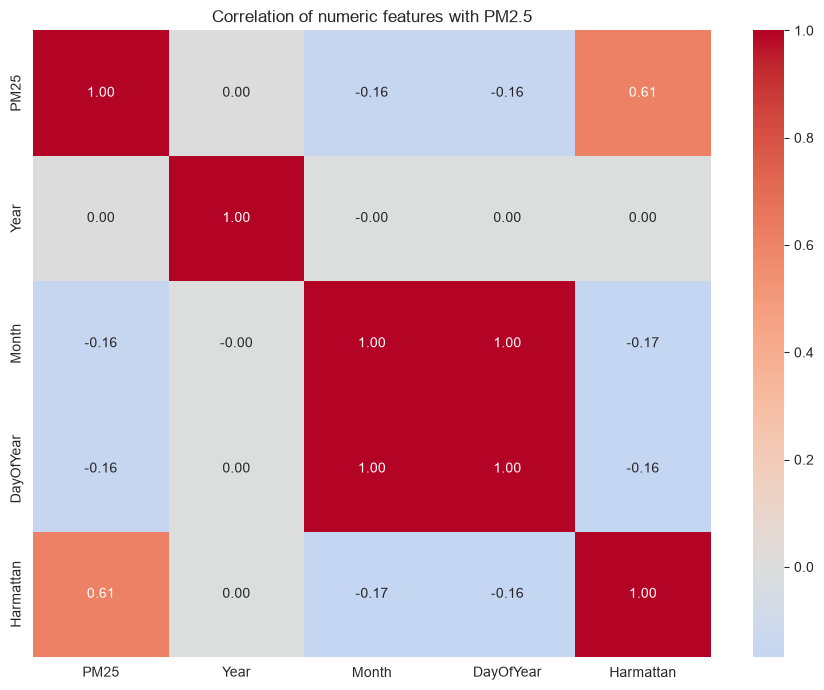

In [9]:
plt.figure(figsize=(9, 7))
num_cols = ['PM25', 'Year', 'Month', 'DayOfYear', 'Harmattan']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation of numeric features with PM2.5')
plt.tight_layout()
plt.show()

**Interpretation.** `Harmattan` shows the strongest correlation with PM2.5 of any
numeric feature — confirming season is the dominant temporal driver. `Month` and
`DayOfYear` correlate weakly on their own because the relationship is *cyclical* (high at
both ends of the year, low in the middle), which a linear correlation cannot capture well
— an early hint that non-linear models will outperform a straight line.

### 5.2 Distribution of the target (PM2.5)

C:\Users\AKINLOYE\AppData\Local\Temp\ipykernel_980\2274117812.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(['Non-Harmattan', 'Harmattan'])


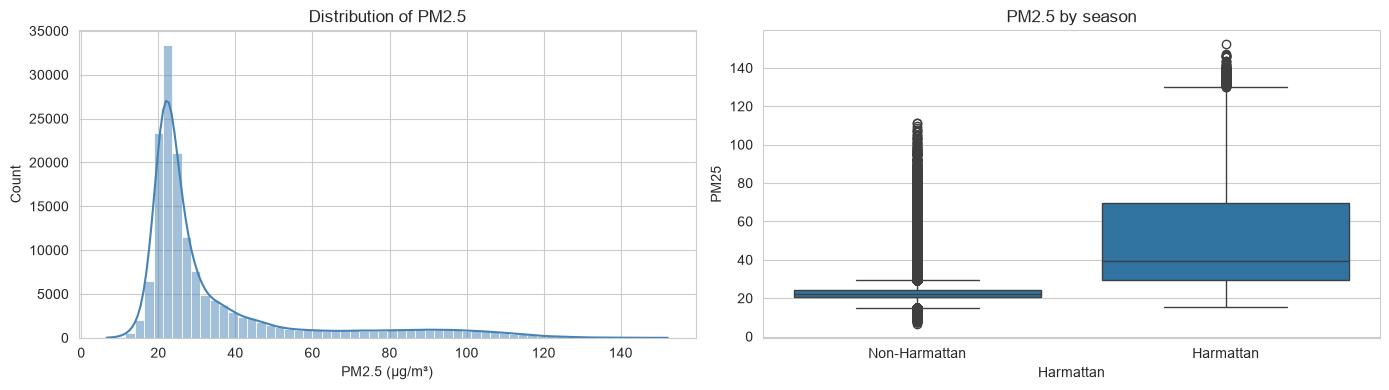

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['PM25'], bins=60, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Distribution of PM2.5')
ax[0].set_xlabel('PM2.5 (µg/m³)')

sns.boxplot(x='Harmattan', y='PM25', data=df, ax=ax[1])
ax[1].set_xticklabels(['Non-Harmattan', 'Harmattan'])
ax[1].set_title('PM2.5 by season')
plt.tight_layout()
plt.show()

**Interpretation.** PM2.5 is **right-skewed** — most days are moderate but a long
tail of high-pollution days exists (the Harmattan spikes). The boxplot makes the seasonal
split explicit: Harmattan days have a much higher median and many more extreme values.
This skew and the season-driven spikes are exactly what the models must learn.

### 5.3 Average PM2.5 by city

C:\Users\AKINLOYE\AppData\Local\Temp\ipykernel_980\1311859596.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_means.values, y=city_means.index, palette='viridis')


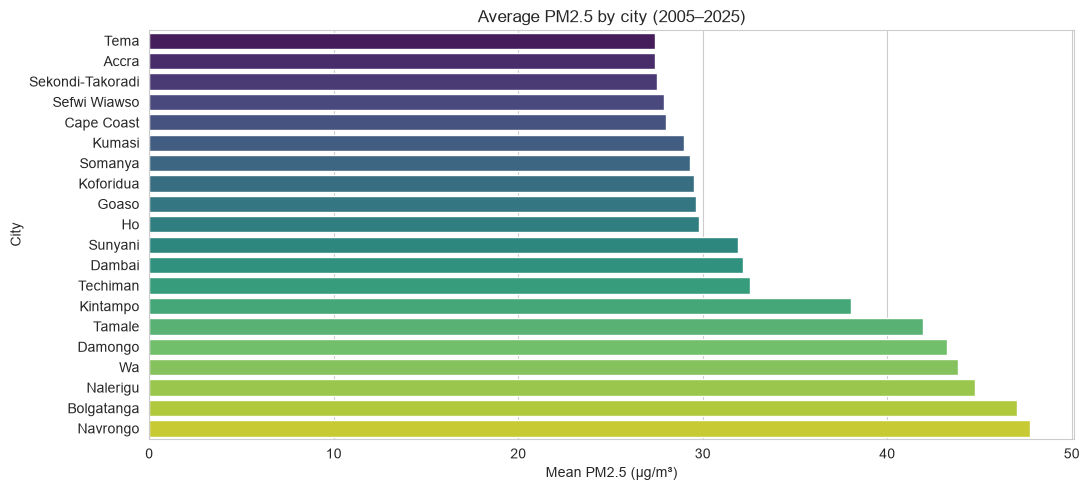

In [11]:
plt.figure(figsize=(11, 5))
city_means = df.groupby('City')['PM25'].mean().sort_values()
sns.barplot(x=city_means.values, y=city_means.index, palette='viridis')
plt.xlabel('Mean PM2.5 (µg/m³)')
plt.title('Average PM2.5 by city (2005–2025)')
plt.tight_layout()
plt.show()

**Interpretation.** Northern cities (e.g. Tamale, Navrongo, Bolgatanga) sit closer
to the Sahel and record higher average PM2.5 than coastal southern cities (e.g. Cape
Coast, Accra). This geographic spread justifies keeping `City` as a predictor via one-hot
encoding.

## 6. Define features/target, split, and standardize

We fit the scaler on the **training set only** and reuse it on the test set to avoid data
leakage. The fitted scaler is saved because the API must apply the identical
transformation at prediction time.

In [12]:
y = df_encoded['PM25']
X = df_encoded.drop(columns=['PM25'])
feature_columns = list(X.columns)
print('Number of features:', len(feature_columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)

Number of features: 23
Train: (122720, 23)  Test: (30680, 23)


## 7. Train three regression models

We compare **Linear Regression (via stochastic gradient descent)**, **Random Forest**,
and **Decision Tree**, all from scikit-learn, and evaluate each by MSE / RMSE / R².

In [13]:
results = {}

# 1) Linear Regression via Stochastic Gradient Descent
sgd = SGDRegressor(max_iter=1000, penalty='l2', eta0=0.01,
                   learning_rate='invscaling', random_state=42)
sgd.fit(X_train_s, y_train)
pred = sgd.predict(X_test_s)
results['Linear (SGD)'] = {'model': sgd,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

# 2) Random Forest
# Depth/leaf are capped so the saved model stays small enough to deploy
# (an unconstrained forest on 120k+ rows serialises to ~1 GB).
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
pred = rf.predict(X_test_s)
results['Random Forest'] = {'model': rf,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

# 3) Decision Tree
dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
dt.fit(X_train_s, y_train)
pred = dt.predict(X_test_s)
results['Decision Tree'] = {'model': dt,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

summary = pd.DataFrame({k: {'MSE': v['MSE'], 'RMSE': v['MSE']**0.5, 'R2': v['R2']}
                        for k, v in results.items()}).T
summary

,MSE,RMSE,R2
Linear (SGD),279.061835,16.705144,0.469619
Random Forest,75.842393,8.708754,0.855855
Decision Tree,115.781877,10.760199,0.779946


**Interpretation.** Random Forest achieves the lowest error (highest R²). The linear
model underfits because the season×city relationship is non-linear — a straight line
cannot bend to the cyclical pattern the trees capture. This is the core justification for
selecting the Random Forest.

## 8. Loss curve — training vs test error over epochs

We retrain the SGD linear model epoch-by-epoch with `partial_fit`, recording train and
test MSE each epoch, to visualise convergence.

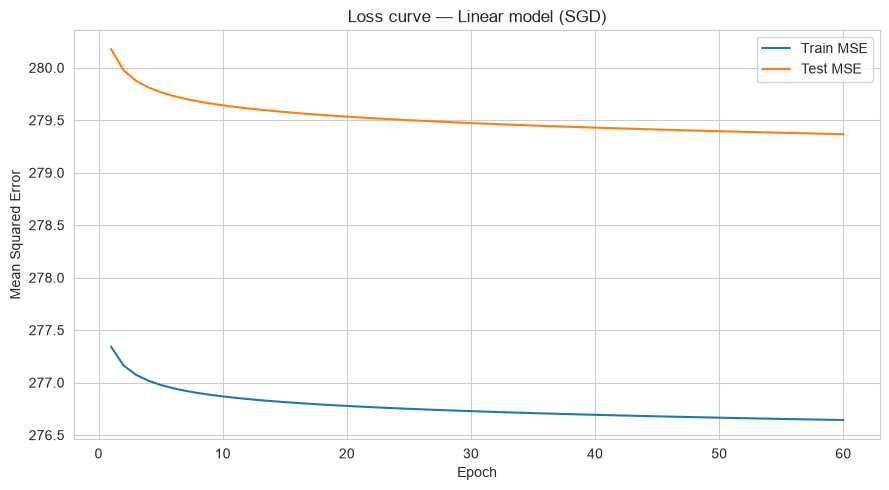

In [14]:
from sklearn.linear_model import SGDRegressor as SGD2
sgd_lc = SGD2(max_iter=1, warm_start=True, penalty='l2', eta0=0.01,
              learning_rate='invscaling', random_state=42, tol=None)

epochs = 60
train_loss, test_loss = [], []
for _ in range(epochs):
    sgd_lc.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd_lc.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd_lc.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs+1), train_loss, label='Train MSE')
plt.plot(range(1, epochs+1), test_loss, label='Test MSE')
plt.xlabel('Epoch'); plt.ylabel('Mean Squared Error')
plt.title('Loss curve — Linear model (SGD)')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Train and test loss fall together and flatten, with no widening
gap — the linear model is **not overfitting**; it has simply reached the ceiling of what a
linear fit can achieve on this data. Reducing error further requires a more expressive
model (Random Forest) or richer features (e.g. weather).

## 9. Scatter plot with fitted regression line

We plot actual PM2.5 against `DayOfYear` and overlay the linear model's predictions to
show where the fitted line passes through the data.

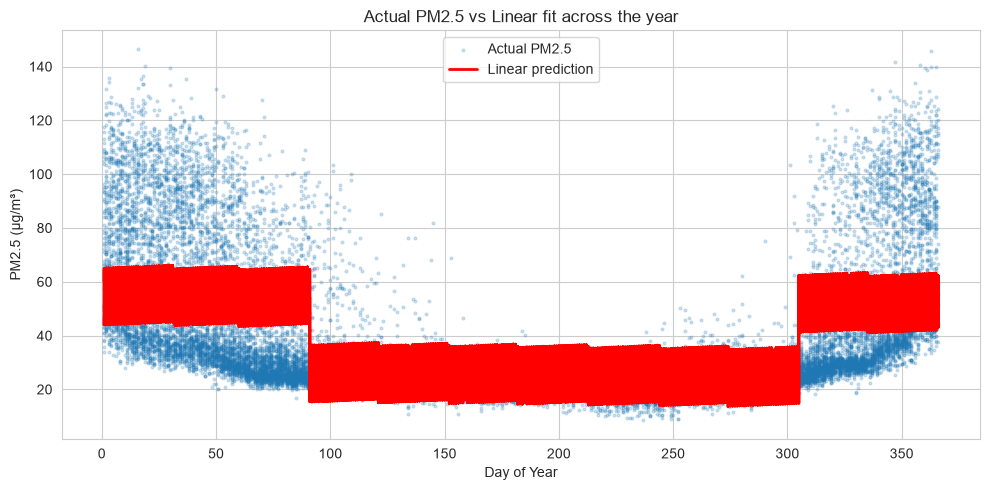

In [15]:
order = np.argsort(X_test['DayOfYear'].values)
day_sorted = X_test['DayOfYear'].values[order]
actual_sorted = y_test.values[order]
pred_line = sgd.predict(X_test_s)[order]

plt.figure(figsize=(10, 5))
plt.scatter(day_sorted, actual_sorted, s=4, alpha=0.2, label='Actual PM2.5')
plt.plot(day_sorted, pred_line, color='red', linewidth=2, label='Linear prediction')
plt.xlabel('Day of Year'); plt.ylabel('PM2.5 (µg/m³)')
plt.title('Actual PM2.5 vs Linear fit across the year')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** PM2.5 is high at the start and end of the year (Harmattan) and
low mid-year. The linear fit slopes through the cloud but cannot follow the U-shape — a
clear visual reason the non-linear Random Forest scores better.

## 10. Save the best model

The model with the lowest test MSE is saved, along with the scaler and the exact feature
column order, which the API needs to reproduce the same preprocessing.

In [ ]:
best_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_name]['model']
print('Best model:', best_name, '| RMSE =', round(results[best_name]['MSE']**0.5, 2))

joblib.dump(best_model, 'best_model.pkl', compress=3)  
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')
print('Saved: best_model.pkl, scaler.pkl, feature_columns.pkl')

Best model: Random Forest | RMSE = 8.71
Saved: best_model.pkl, scaler.pkl, feature_columns.pkl


In [17]:
import os
print('Model file size: %.1f MB' % (os.path.getsize('best_model.pkl')/1e6))

Model file size: 23.9 MB


## 11. Single-row prediction (feeds the API in Task 2)

Take one row from the test set, run it through the saved scaler + model, and compare the
prediction to the true value.

In [18]:
def predict_single(row_df, model, scaler, feature_columns):
    """Predict PM2.5 for one row (a DataFrame with the feature columns)."""
    row_ordered = row_df[feature_columns]
    row_scaled = scaler.transform(row_ordered)
    return float(model.predict(row_scaled)[0])

sample = X_test.iloc[[0]]
predicted = predict_single(sample, best_model, scaler, feature_columns)
print('Predicted PM2.5:', round(predicted, 2))
print('Actual PM2.5:   ', round(float(y_test.iloc[0]), 2))

Predicted PM2.5: 22.0
Actual PM2.5:    24.1


## 12. Hyperparameters & reducing error (for the video)

**What lowered the error, in order of impact**
1. **Feature engineering** — turning the date string into `Month` / `DayOfYear` /
   `Harmattan` gave the model a real seasonal signal (the biggest single win).
2. **Standardization** — scaling features so SGD converges and no feature dominates by
   magnitude.
3. **Model choice** — Random Forest captures non-linear season×city interactions a line
   cannot.

**Hyperparameters that tune performance**
- *SGDRegressor:* `eta0`/`learning_rate` (step size), `max_iter`, `penalty` (L1/L2
  regularization).
- *Random Forest:* `n_estimators` (more trees → lower variance), `max_depth`,
  `min_samples_leaf`.
- *Decision Tree:* `max_depth` (main overfitting control), `min_samples_split`.

These would be tuned with `GridSearchCV`. Capping `max_depth` and raising `n_estimators`
trade variance for bias to reduce test error.
